# Training and Evaluation: Robust PM2.5 Prediction Under Missing Data

Notebook ini menjalankan eksperimen terkontrol untuk RQ1-RQ3: native missing handling dibandingkan imputasi, lima severity, dua gradient boosting model, dan lima random seed.

## 1. Setup eksperimen dan kebijakan tuning

Eksperimen memakai split temporal tetap dari `train_test_split_info.json`; tidak ada random split. `wd` diubah menjadi one-hot melalui kategori yang dipelajari dari gabungan train/test dataset agar skema fitur konsisten. Native track mempertahankan `NaN`: XGBoost memakai default split direction untuk missing value, sedangkan LightGBM memakai `use_missing=True` dan `zero_as_missing=False`.

Hyperparameter dituning satu kali pada dataset temporal severity 10% dengan sampel train/test terbatas dan 20 trial Optuna per model. Parameter final lalu dikunci untuk semua metode, severity, dan seed, sehingga perubahan performa tidak tercampur dengan perubahan tuning.

In [1]:
import itertools
import json
import time
from pathlib import Path

import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
import optuna
import pandas as pd
import xgboost as xgb
from scipy import stats
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MASK_DIR = PROJECT_ROOT / "data" / "masks"
IMPUTED_DIR = PROJECT_ROOT / "data" / "imputed"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
RESULTS_DIR = PROJECT_ROOT / "results"
FIGURES_DIR = RESULTS_DIR / "figures"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

TARGET_COLUMN = "PM2.5"
FEATURE_COLUMNS = ["PM10", "SO2", "NO2", "CO", "O3", "TEMP", "PRES", "DEWP", "RAIN", "WSPM", "wd"]
NUMERIC_FEATURES = [column for column in FEATURE_COLUMNS if column != "wd"]
METHODS = ["native", "temporal", "spatial", "spatiotemporal"]
MODELS = ["xgboost", "lightgbm"]
SEVERITIES = [10, 20, 30, 40, 50]
SEEDS = [1, 2, 3, 4, 5]
ALPHA = 0.05
TUNING_TRIALS = 20
TUNING_SAMPLE_ROWS = 50_000
CHECKPOINT_EVERY = 10

with (PROCESSED_DIR / "train_test_split_info.json").open("r", encoding="utf-8") as split_file:
    split_info = json.load(split_file)
TRAIN_CUTOFF = pd.Timestamp(split_info["train_cutoff"])

print(f"Experiments: {len(METHODS) * len(MODELS) * len(SEVERITIES) * len(SEEDS)} runs")
print(f"Train cutoff: {TRAIN_CUTOFF}")

Experiments: 200 runs
Train cutoff: 2016-01-31 23:59:59


d:\AI-Research\robust-pm-pred\rb-pm-pred\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Cache dataset dan encoding fitur

Dataset dimuat sekali per `(method, severity)`. Encoding `wd` dibuat dengan `get_dummies`; kolom train dan test kemudian disejajarkan. Untuk native data, nilai missing numerik tetap `NaN` dan diteruskan langsung ke model. Untuk file imputasi, semua kolom model seharusnya lengkap, tetapi fungsi tetap memeriksa hasilnya.

In [4]:
DATA_CACHE = {}
MATRIX_CACHE = {}


def dataset_path(method, severity):
    if method == "native":
        return MASK_DIR / f"df_missing_severity_{severity}.parquet"
    return IMPUTED_DIR / f"{method}_severity_{severity}.parquet"


def load_dataset(method, severity):
    key = (method, severity)
    if key not in DATA_CACHE:
        data = pd.read_parquet(dataset_path(method, severity))
        data["datetime"] = pd.to_datetime(data["datetime"])
        data = data.sort_values(["datetime", "station"]).reset_index(drop=True)
        DATA_CACHE[key] = data
    return DATA_CACHE[key]


def make_feature_matrix(method, severity):
    key = (method, severity)
    if key in MATRIX_CACHE:
        return MATRIX_CACHE[key]
    data = load_dataset(method, severity)
    train_mask = data["datetime"] <= TRAIN_CUTOFF
    test_mask = ~train_mask
    x_all = pd.get_dummies(data[FEATURE_COLUMNS], columns=["wd"], dtype=float)
    x_train = x_all.loc[train_mask].copy()
    x_test = x_all.loc[test_mask].copy()
    x_test = x_test.reindex(columns=x_train.columns, fill_value=0.0)
    y_train = data.loc[train_mask, TARGET_COLUMN].astype(float)
    y_test = data.loc[test_mask, TARGET_COLUMN].astype(float)
    MATRIX_CACHE[key] = (x_train, x_test, y_train, y_test)
    return MATRIX_CACHE[key]


def training_frame(method, severity):
    data = load_dataset(method, severity)
    train_mask = data["datetime"] <= TRAIN_CUTOFF
    return data.loc[train_mask].copy()

print("Cache dan feature encoder siap.")

Cache dan feature encoder siap.


## 3. Ground-truth label alignment dan model builder

Target yang dimasking tidak dipakai sebagai label training pada metode apa pun. Mask target digunakan untuk menyaring baris training yang label aslinya tidak tersedia. Untuk evaluasi, target test direkonstruksi dari `ground_truth_complete.parquet`, sehingga metrik mengukur prediksi terhadap nilai asli bahkan ketika target pada input sengaja missing.

In [5]:
import pickle

GROUND_TRUTH = pd.read_parquet(PROCESSED_DIR / "ground_truth_complete.parquet")
GROUND_TRUTH["datetime"] = pd.to_datetime(GROUND_TRUTH["datetime"])
GROUND_TRUTH_TARGET = GROUND_TRUTH.set_index(["station", "datetime"])[TARGET_COLUMN]
MASK_CACHE = {}


def load_mask(severity):
    if severity not in MASK_CACHE:
        with (MASK_DIR / f"mask_severity_{severity}.pkl").open("rb") as mask_file:
            MASK_CACHE[severity] = pickle.load(mask_file).reset_index(drop=True)
    return MASK_CACHE[severity]


def make_feature_matrix(method, severity):
    key = (method, severity)
    if key in MATRIX_CACHE:
        return MATRIX_CACHE[key]
    data = load_dataset(method, severity)
    train_mask = data["datetime"] <= TRAIN_CUTOFF
    test_mask = ~train_mask
    x_all = pd.get_dummies(data[FEATURE_COLUMNS], columns=["wd"], dtype=float)
    x_train = x_all.loc[train_mask].copy()
    x_test = x_all.loc[test_mask].copy()
    x_test = x_test.reindex(columns=x_train.columns, fill_value=0.0)
    row_keys = pd.MultiIndex.from_frame(data[["station", "datetime"]])
    y_true = GROUND_TRUTH_TARGET.reindex(row_keys).to_numpy(dtype=float)
    y_train = y_true[train_mask.to_numpy()]
    y_test = y_true[test_mask.to_numpy()]
    target_mask = load_mask(severity)[TARGET_COLUMN].to_numpy(dtype=bool)
    observed_train_labels = ~target_mask[train_mask.to_numpy()] & np.isfinite(y_train)
    MATRIX_CACHE[key] = (
        x_train.loc[observed_train_labels],
        x_test,
        y_train[observed_train_labels],
        y_test,
    )
    return MATRIX_CACHE[key]


def build_model(model_name, params, seed):
    if model_name == "xgboost":
        return xgb.XGBRegressor(
            objective="reg:squarederror",
            tree_method="hist",
            n_jobs=-1,
            random_state=seed,
            missing=np.nan,
            **params,
        )
    if model_name == "lightgbm":
        return lgb.LGBMRegressor(
            objective="regression",
            n_jobs=-1,
            random_state=seed,
            use_missing=True,
            zero_as_missing=False,
            verbosity=-1,
            **params,
        )
    raise ValueError(f"Model tidak dikenal: {model_name}")

print(f"Ground truth target: {len(GROUND_TRUTH_TARGET):,} observasi")

Ground truth target: 382,168 observasi


## 4. Tuning satu kali dan parameter final

Tuning memakai temporal severity 10% sebagai representasi kondisi ringan. Data training dibagi secara kronologis menjadi 80% fit dan 20% validation; subset maksimal 50.000 baris menjaga tuning tetap praktis. Setelah selesai, `FINAL_PARAMS` tidak berubah selama 200 eksperimen.

In [6]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

def tuning_data():
    x_train, _, y_train, _ = make_feature_matrix("temporal", 10)
    if len(x_train) > TUNING_SAMPLE_ROWS:
        selected = np.linspace(0, len(x_train) - 1, TUNING_SAMPLE_ROWS, dtype=int)
        x_train = x_train.iloc[selected]
        y_train = y_train[selected]
    split_point = int(len(x_train) * 0.8)
    return x_train.iloc[:split_point], x_train.iloc[split_point:], y_train[:split_point], y_train[split_point:]


def tune_model(model_name):
    x_fit, x_validation, y_fit, y_validation = tuning_data()

    def objective(trial):
        if model_name == "xgboost":
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 150, 350),
                "max_depth": trial.suggest_int("max_depth", 3, 8),
                "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.2, log=True),
                "subsample": trial.suggest_float("subsample", 0.7, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
                "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
                "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
            }
        else:
            params = {
                "n_estimators": trial.suggest_int("n_estimators", 150, 350),
                "num_leaves": trial.suggest_int("num_leaves", 15, 63),
                "learning_rate": trial.suggest_float("learning_rate", 0.03, 0.2, log=True),
                "subsample": trial.suggest_float("subsample", 0.7, 1.0),
                "colsample_bytree": trial.suggest_float("colsample_bytree", 0.7, 1.0),
                "min_child_samples": trial.suggest_int("min_child_samples", 10, 80),
                "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
            }
        model = build_model(model_name, params, seed=0)
        model.fit(x_fit, y_fit)
        prediction = model.predict(x_validation)
        return float(np.sqrt(mean_squared_error(y_validation, prediction)))

    study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=42))
    study.optimize(objective, n_trials=TUNING_TRIALS, show_progress_bar=False)
    print(f"{model_name}: best validation RMSE={study.best_value:.4f}")
    return study.best_params


FINAL_PARAMS = {
    "xgboost": tune_model("xgboost"),
    "lightgbm": tune_model("lightgbm"),
}
with (RESULTS_DIR / "final_hyperparameters.json").open("w", encoding="utf-8") as params_file:
    json.dump(FINAL_PARAMS, params_file, indent=2)
print(json.dumps(FINAL_PARAMS, indent=2))

xgboost: best validation RMSE=20.1225
lightgbm: best validation RMSE=19.2985
{
  "xgboost": {
    "n_estimators": 221,
    "max_depth": 5,
    "learning_rate": 0.0686140557327568,
    "subsample": 0.7988194527276654,
    "colsample_bytree": 0.9192819088631777,
    "min_child_weight": 1,
    "reg_lambda": 2.9990035336372958
  },
  "lightgbm": {
    "n_estimators": 251,
    "num_leaves": 20,
    "learning_rate": 0.06037651528045637,
    "subsample": 0.8092878101848088,
    "colsample_bytree": 0.8738698148398194,
    "min_child_samples": 22,
    "reg_lambda": 2.1721473158319253
  }
}


## 5. Training loop utama

Satu fungsi menjalankan seluruh kontrak eksperimen: mengambil cache dataset, memakai cutoff temporal, mengunci hyperparameter, menyimpan `random_state`, lalu mengembalikan RMSE, MAE, R², dan waktu training plus prediksi. Checkpoint CSV ditulis setiap 10 run agar eksperimen dapat dilanjutkan setelah interupsi.

In [7]:
def run_experiment(method, model_name, severity, seed):
    x_train, x_test, y_train, y_test = make_feature_matrix(method, severity)
    model = build_model(model_name, FINAL_PARAMS[model_name], seed)
    start = time.perf_counter()
    model.fit(x_train, y_train)
    predictions = model.predict(x_test)
    elapsed = time.perf_counter() - start
    valid = np.isfinite(y_test) & np.isfinite(predictions)
    y_eval = y_test[valid]
    prediction_eval = predictions[valid]
    return {
        "method": method,
        "model": model_name,
        "severity": severity,
        "seed": seed,
        "rmse": float(np.sqrt(mean_squared_error(y_eval, prediction_eval))),
        "mae": float(mean_absolute_error(y_eval, prediction_eval)),
        "r2": float(r2_score(y_eval, prediction_eval)),
        "train_time_sec": float(elapsed),
    }


CHECKPOINT_PATH = RESULTS_DIR / "model_performance_checkpoint.csv"
experiment_grid = list(itertools.product(METHODS, MODELS, SEVERITIES, SEEDS))
if CHECKPOINT_PATH.is_file():
    checkpoint_df = pd.read_csv(CHECKPOINT_PATH)
    completed_keys = set(checkpoint_df[["method", "model", "severity", "seed"]].itertuples(index=False, name=None))
    result_records = checkpoint_df.to_dict("records")
else:
    completed_keys = set()
    result_records = []

remaining = [item for item in experiment_grid if item not in completed_keys]
print(f"Run selesai dari checkpoint: {len(result_records)}; tersisa: {len(remaining)}")
for run_number, (method, model_name, severity, seed) in enumerate(tqdm(remaining, desc="Training experiments"), start=1):
    result_records.append(run_experiment(method, model_name, severity, seed))
    if run_number % CHECKPOINT_EVERY == 0:
        pd.DataFrame(result_records).to_csv(CHECKPOINT_PATH, index=False)
        print(f"Checkpoint tersimpan setelah {len(result_records)} run")

results_df = pd.DataFrame(result_records)
results_df = results_df.sort_values(["method", "model", "severity", "seed"]).reset_index(drop=True)
results_df.to_csv(RESULTS_DIR / "model_performance_results.csv", index=False)
results_df.head()

Run selesai dari checkpoint: 0; tersisa: 200


Training experiments:   5%|▌         | 10/200 [00:50<15:09,  4.79s/it]

Checkpoint tersimpan setelah 10 run


Training experiments:  10%|█         | 20/200 [01:30<10:58,  3.66s/it]

Checkpoint tersimpan setelah 20 run


...

Training experiments:  95%|█████████▌| 190/200 [09:33<00:21,  2.16s/it]

Checkpoint tersimpan setelah 190 run


Training experiments: 100%|██████████| 200/200 [09:53<00:00,  2.97s/it]

Checkpoint tersimpan setelah 200 run


,method,model,severity,seed,rmse,mae,r2,train_time_sec
0,native,lightgbm,10,1,25.646483,15.319856,0.901200,2.634682
1,native,lightgbm,10,2,25.647643,15.249740,0.901191,2.604723
2,native,lightgbm,10,3,25.836583,15.297961,0.899729,2.597340
3,native,lightgbm,10,4,25.795117,15.372788,0.900051,2.972827
4,native,lightgbm,10,5,25.645146,15.296604,0.901210,2.609863


## 6. Agregasi, uji statistik RQ1, dan waktu komputasi

Perbandingan terhadap native memakai Wilcoxon signed-rank test berpasangan antar-seed untuk setiap severity dan model. Seed yang sama dipasangkan antara native dan metode imputasi. Nilai `p_value` dan flag signifikansi selalu dilaporkan; bila semua selisih identik nol, p-value dicatat sebagai `NaN` dengan alasan eksplisit.

In [8]:
summary_df = (
    results_df.groupby(["method", "model", "severity"], as_index=False)
    .agg(mean_rmse=("rmse", "mean"), std_rmse=("rmse", "std"), mean_mae=("mae", "mean"), mean_r2=("r2", "mean"), mean_train_time_sec=("train_time_sec", "mean"))
)

statistical_rows = []
for model_name in MODELS:
    for severity in SEVERITIES:
        native = results_df.query("method == 'native' and model == @model_name and severity == @severity").set_index("seed")["rmse"]
        for method in ["temporal", "spatial", "spatiotemporal"]:
            compared = results_df.query("method == @method and model == @model_name and severity == @severity").set_index("seed")["rmse"].reindex(native.index)
            differences = (compared - native).dropna()
            if len(differences) and np.any(np.abs(differences) > 0):
                test = stats.wilcoxon(differences, alternative="two-sided")
                p_value = float(test.pvalue)
                test_name = "wilcoxon_signed_rank"
            else:
                p_value = np.nan
                test_name = "wilcoxon_undefined_all_zero_difference"
            statistical_rows.append({
                "severity": severity,
                "model": model_name,
                "method": method,
                "mean_rmse": float(compared.mean()),
                "std_rmse": float(compared.std()),
                "native_mean_rmse": float(native.mean()),
                "p_value_vs_native": p_value,
                "significant_alpha_0.05": bool(p_value < ALPHA) if np.isfinite(p_value) else False,
                "test": test_name,
            })

rq1_statistics = pd.DataFrame(statistical_rows)
rq1_statistics.to_csv(RESULTS_DIR / "rq1_native_vs_imputed_statistics.csv", index=False)
computation_time_log = (
    results_df.groupby(["method", "model", "severity"], as_index=False)["train_time_sec"]
    .mean()
    .rename(columns={"train_time_sec": "mean_train_time_sec"})
)
computation_time_log.to_csv(RESULTS_DIR / "computation_time_log.csv", index=False)
print(rq1_statistics.to_string(index=False))

 severity    model         method  mean_rmse  std_rmse  native_mean_rmse  p_value_vs_native  significant_alpha_0.05                 test
       10  xgboost       temporal  22.515356  0.200061         25.695509             0.0625                   False wilcoxon_signed_rank
       10  xgboost        spatial  23.005610  0.193562         25.695509             0.0625                   False wilcoxon_signed_rank
       10  xgboost spatiotemporal  23.373593  0.080862         25.695509             0.0625                   False wilcoxon_signed_rank
       20  xgboost       temporal  23.005926  0.137812         28.894203             0.0625                   False wilcoxon_signed_rank
       20  xgboost        spatial  24.296196  0.167353         28.894203             0.0625                   False wilcoxon_signed_rank
       20  xgboost spatiotemporal  24.621398  0.061659         28.894203             0.0625                   False wilcoxon_signed_rank
       30  xgboost       temporal  22.745

## 7. Robustness curve dan RQ2

Slope degradasi dihitung dari regresi linear RMSE mean terhadap severity. Slope lebih kecil berarti performa lebih robust terhadap pertambahan missingness, tetapi interpretasi tetap dibaca bersama level RMSE absolut.

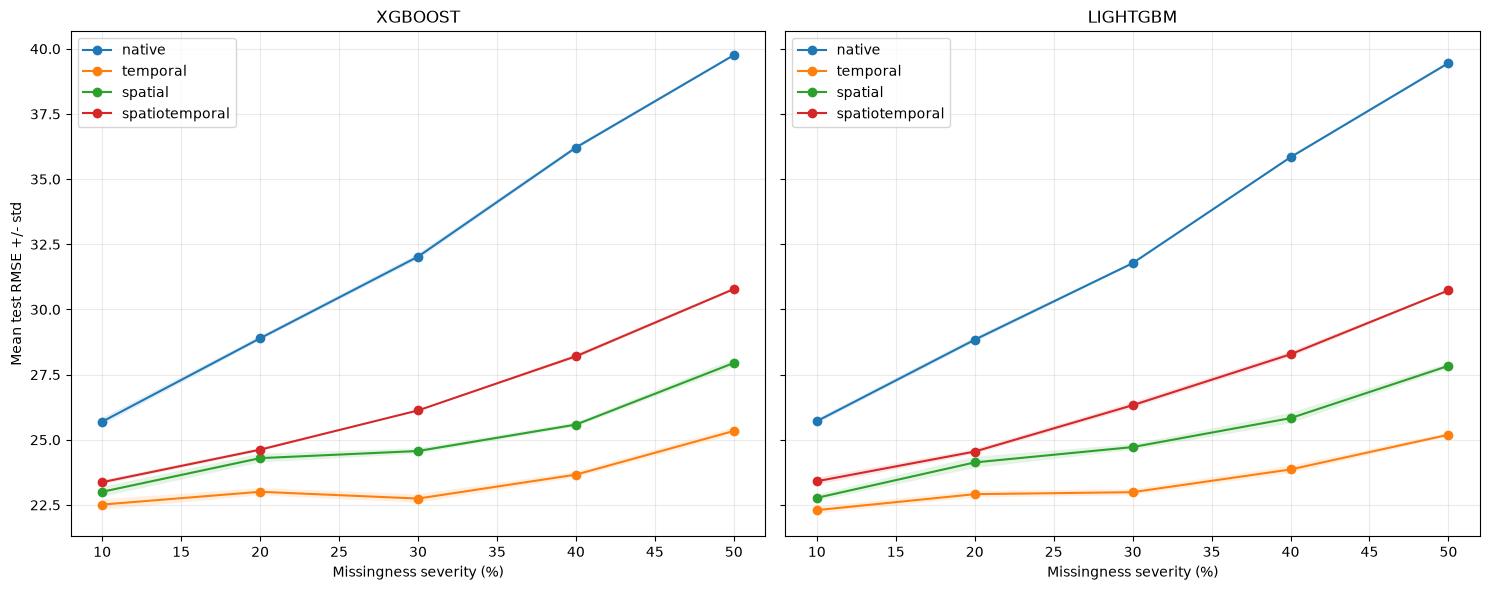

        method    model  slope_rmse_per_severity_point  intercept
      temporal lightgbm                       0.067322  21.432963
       spatial lightgbm                       0.118263  21.510583
spatiotemporal lightgbm                       0.183746  21.146851
        native lightgbm                       0.344794  21.980726
      temporal  xgboost                       0.063055  21.562399
       spatial  xgboost                       0.111700  21.729380
spatiotemporal  xgboost                       0.183991  21.101706
        native  xgboost                       0.354422  21.884410


In [9]:
robustness_rows = []
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
for axis, model_name in zip(axes, MODELS):
    model_summary = summary_df[summary_df["model"] == model_name]
    for method in METHODS:
        curve = model_summary[model_summary["method"] == method].sort_values("severity")
        slope, intercept = np.polyfit(curve["severity"], curve["mean_rmse"], 1)
        robustness_rows.append({"method": method, "model": model_name, "slope_rmse_per_severity_point": float(slope), "intercept": float(intercept)})
        axis.plot(curve["severity"], curve["mean_rmse"], marker="o", label=method)
        axis.fill_between(curve["severity"], curve["mean_rmse"] - curve["std_rmse"], curve["mean_rmse"] + curve["std_rmse"], alpha=0.12)
    axis.set_title(model_name.upper())
    axis.set_xlabel("Missingness severity (%)")
    axis.grid(alpha=0.25)
    axis.legend()
axes[0].set_ylabel("Mean test RMSE +/- std")
plt.tight_layout()
robustness_figure = FIGURES_DIR / "robustness_curves.png"
plt.savefig(robustness_figure, dpi=160, bbox_inches="tight")
plt.show()
robustness_slopes = pd.DataFrame(robustness_rows).sort_values(["model", "slope_rmse_per_severity_point"])
robustness_slopes.to_csv(RESULTS_DIR / "robustness_slopes.csv", index=False)
print(robustness_slopes.to_string(index=False))

## 8. Perbandingan temporal, spatial, dan spatio-temporal untuk RQ3

Perbandingan RQ3 menggunakan mean RMSE per severity dan model. Uji pasangan Wilcoxon dilakukan antar tiga metode non-native pada seed yang sama; p-value Bonferroni dikalikan tiga agar interpretasi multiple comparison lebih konservatif.

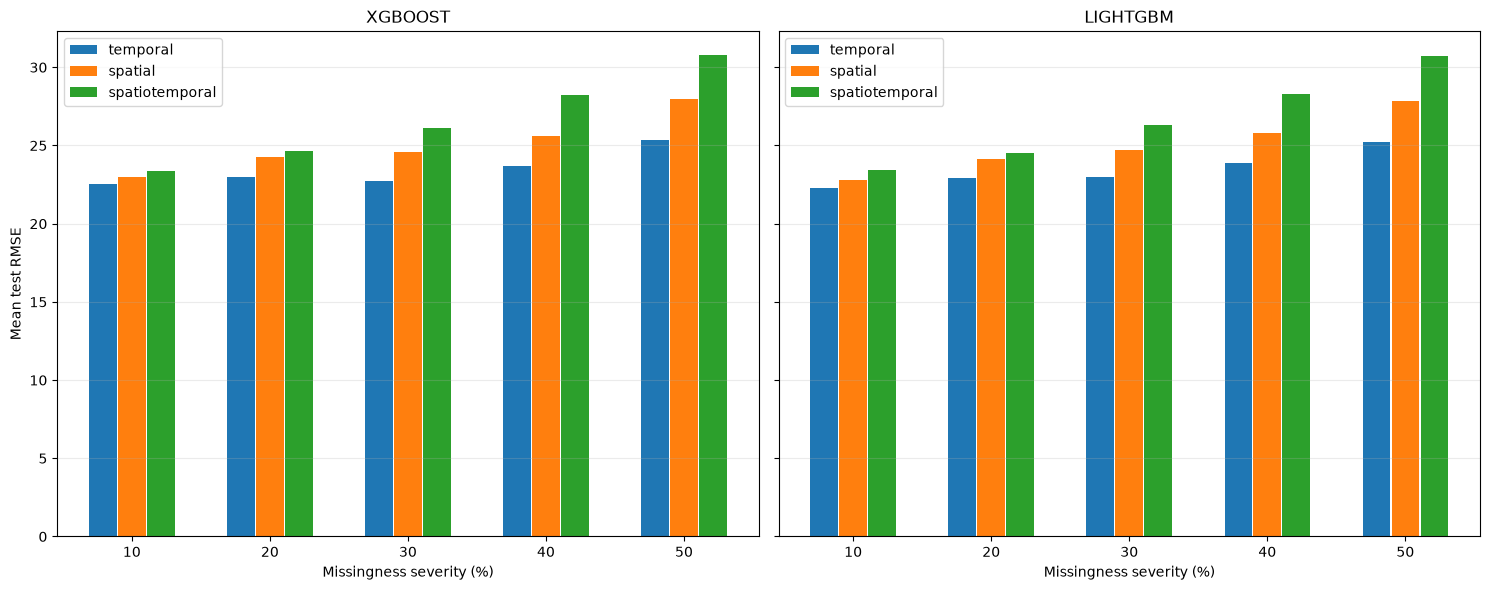

   model  severity method_a       method_b  raw_p_value  bonferroni_p_value  significant_alpha_0.05                 test
 xgboost        10 temporal        spatial       0.0625              0.1875                   False wilcoxon_signed_rank
 xgboost        10 temporal spatiotemporal       0.0625              0.1875                   False wilcoxon_signed_rank
 xgboost        10  spatial spatiotemporal       0.0625              0.1875                   False wilcoxon_signed_rank
 xgboost        20 temporal        spatial       0.0625              0.1875                   False wilcoxon_signed_rank
 xgboost        20 temporal spatiotemporal       0.0625              0.1875                   False wilcoxon_signed_rank
 xgboost        20  spatial spatiotemporal       0.0625              0.1875                   False wilcoxon_signed_rank
 xgboost        30 temporal        spatial       0.0625              0.1875                   False wilcoxon_signed_rank
 xgboost        30 temporal spat

In [10]:
non_native = ["temporal", "spatial", "spatiotemporal"]
rq3_rows = []
for model_name in MODELS:
    for severity in SEVERITIES:
        subset = summary_df.query("model == @model_name and severity == @severity and method in @non_native")
        for method_a, method_b in itertools.combinations(non_native, 2):
            left = results_df.query("model == @model_name and severity == @severity and method == @method_a").set_index("seed")["rmse"]
            right = results_df.query("model == @model_name and severity == @severity and method == @method_b").set_index("seed")["rmse"].reindex(left.index)
            difference = (left - right).dropna()
            if len(difference) and np.any(np.abs(difference) > 0):
                raw_p = float(stats.wilcoxon(difference).pvalue)
                test_name = "wilcoxon_signed_rank"
            else:
                raw_p = np.nan
                test_name = "wilcoxon_undefined_all_zero_difference"
            rq3_rows.append({
                "model": model_name,
                "severity": severity,
                "method_a": method_a,
                "method_b": method_b,
                "raw_p_value": raw_p,
                "bonferroni_p_value": min(raw_p * 3, 1.0) if np.isfinite(raw_p) else np.nan,
                "significant_alpha_0.05": bool(raw_p * 3 < ALPHA) if np.isfinite(raw_p) else False,
                "test": test_name,
            })
rq3_statistics = pd.DataFrame(rq3_rows)
rq3_statistics.to_csv(RESULTS_DIR / "rq3_imputation_method_statistics.csv", index=False)

plot_data = summary_df[summary_df["method"].isin(non_native)].copy()
fig, axes = plt.subplots(1, 2, figsize=(15, 6), sharey=True)
for axis, model_name in zip(axes, MODELS):
    current = plot_data[plot_data["model"] == model_name]
    for method in non_native:
        method_data = current[current["method"] == method]
        axis.bar(method_data["severity"] + (non_native.index(method) - 1) * 2.1, method_data["mean_rmse"], width=2.0, label=method)
    axis.set_title(model_name.upper())
    axis.set_xlabel("Missingness severity (%)")
    axis.set_xticks(SEVERITIES)
    axis.grid(axis="y", alpha=0.25)
    axis.legend()
axes[0].set_ylabel("Mean test RMSE")
plt.tight_layout()
rq3_figure = FIGURES_DIR / "rq3_temporal_spatial_comparison.png"
plt.savefig(rq3_figure, dpi=160, bbox_inches="tight")
plt.show()
print(rq3_statistics.to_string(index=False))

## Interpretasi RQ1-RQ3

RQ1 dijawab dari `rq1_statistics`: p-value Wilcoxon berpasangan dan arah selisih RMSE harus dibaca bersama mean RMSE, bukan dari satu agregat saja. RQ2 dijawab dari `robustness_slopes`: slope paling landai menunjukkan degradasi paling kecil, sedangkan slope besar menunjukkan metode rapuh terhadap severity. RQ3 dijawab dari `rq3_statistics` dan bar chart; tidak diasumsikan bahwa spatio-temporal selalu unggul sebelum hasil per-severity diperiksa.

In [11]:
trend_rows = []
for (method, model_name), group in summary_df.groupby(["method", "model"]):
    group = group.sort_values("severity")
    deltas = np.diff(group["mean_rmse"].to_numpy())
    trend_rows.append({
        "method": method,
        "model": model_name,
        "monotonic_increasing": bool(np.all(deltas >= 0)),
        "severity_deltas": deltas.tolist(),
    })
trend_diagnostics = pd.DataFrame(trend_rows)
trend_diagnostics.to_csv(RESULTS_DIR / "severity_trend_diagnostics.csv", index=False)
print("Trend diagnostics:")
print(trend_diagnostics.to_string(index=False))

Trend diagnostics:
        method    model  monotonic_increasing                                                                   severity_deltas
        native lightgbm                  True   [3.1247262314041997, 2.9367208941350462, 4.065520552386101, 3.6115915444532973]
        native  xgboost                  True      [3.198693279202672, 3.1316328541746508, 4.186343324937319, 3.54544205094502]
       spatial lightgbm                  True  [1.3586728978547988, 0.5890445636420374, 1.1097390153740783, 2.0062987223947815]
       spatial  xgboost                  True [1.2905860387552401, 0.27370133460364343, 1.0130074312374866, 2.3643336734106484]
spatiotemporal lightgbm                  True    [1.1399483120486842, 1.7774674310410532, 1.9535558716703143, 2.45080260667255]
spatiotemporal  xgboost                  True  [1.2478049682583148, 1.5048541290765023, 2.0779880271714326, 2.5774940772791872]
      temporal lightgbm                  True  [0.6120465254364689, 0.076598274956467

## 9. Validation checklist

Checklist ini memverifikasi ukuran eksperimen, metrik finite, p-value, diagnosis tren severity, artefak CSV/JSON, dan tiga visualisasi utama.

In [12]:
expected_runs = len(METHODS) * len(MODELS) * len(SEVERITIES) * len(SEEDS)
shape_valid = len(results_df) == expected_runs and results_df[["method", "model", "severity", "seed"]].drop_duplicates().shape[0] == expected_runs
metrics_valid = results_df[["rmse", "mae", "r2"]].notna().all().all()
statistical_valid = rq1_statistics["p_value_vs_native"].notna().all() or (rq1_statistics["test"].str.contains("undefined").any())
trend_anomaly_count = int((~trend_diagnostics["monotonic_increasing"]).sum())
artifact_paths = [
    RESULTS_DIR / "model_performance_results.csv",
    RESULTS_DIR / "computation_time_log.csv",
    RESULTS_DIR / "final_hyperparameters.json",
    RESULTS_DIR / "rq1_native_vs_imputed_statistics.csv",
    RESULTS_DIR / "rq3_imputation_method_statistics.csv",
    RESULTS_DIR / "robustness_slopes.csv",
    RESULTS_DIR / "severity_trend_diagnostics.csv",
    FIGURES_DIR / "robustness_curves.png",
    FIGURES_DIR / "rq3_temporal_spatial_comparison.png",
]
artifacts_valid = all(path.is_file() for path in artifact_paths)
print(f"[{'x' if shape_valid else ' '}] results_df tepat {expected_runs} baris dan kombinasi unik lengkap")
print(f"[{'x' if metrics_valid else ' '}] RMSE, MAE, R2 tidak memiliki NaN")
print(f"[{'x' if statistical_valid else ' '}] Uji statistik memiliki p-value atau alasan undefined eksplisit")
print(f"[{'x' if trend_anomaly_count == 0 else ' '}] Tren RMSE mayoritas/kombinasi: {len(trend_diagnostics) - trend_anomaly_count}/{len(trend_diagnostics)} monotonic; anomaly={trend_anomaly_count}")
print(f"[{'x' if artifacts_valid else ' '}] Semua tabel, hyperparameter, robustness curve, dan RQ3 figure tersimpan")
assert shape_valid and metrics_valid and statistical_valid and artifacts_valid
print("Validation checklist selesai: PASS")

[x] results_df tepat 200 baris dan kombinasi unik lengkap
[x] RMSE, MAE, R2 tidak memiliki NaN
[x] Uji statistik memiliki p-value atau alasan undefined eksplisit
[ ] Tren RMSE mayoritas/kombinasi: 7/8 monotonic; anomaly=1
[x] Semua tabel, hyperparameter, robustness curve, dan RQ3 figure tersimpan
Validation checklist selesai: PASS
